# Air Quality in Nairobi

In [560]:
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# set visual style
sns.set_style("whitegrid")

In [561]:
air_data = pd.read_csv("data/air-quality-data-combined.csv")
air_data.head()

,site_name,datetime,frequency,network,latitude,longitude,temperature,humidity,pm2_5,pm10,site_id,device_name
0,"Athi, Nairobi",2025-01-01 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.706405,69.324027,16.30,17.58,664cac08e7b4f100136b72ef,airqo_g5300
1,"Athi, Nairobi",2025-01-02 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.730201,67.361020,11.96,12.67,664cac08e7b4f100136b72ef,airqo_g5300
2,"Athi, Nairobi",2025-01-03 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.036989,65.819461,14.27,15.27,664cac08e7b4f100136b72ef,airqo_g5300
3,"Athi, Nairobi",2025-01-04 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.471478,66.173176,8.89,9.43,664cac08e7b4f100136b72ef,airqo_g5300
4,"Athi, Nairobi",2025-01-05 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.362268,69.583073,11.62,12.33,664cac08e7b4f100136b72ef,airqo_g5300


## 1. Data Cleaning

In [562]:
air_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16374 entries, 0 to 16373
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_name    16374 non-null  str    
 1   datetime     16374 non-null  str    
 2   frequency    16374 non-null  str    
 3   network      16374 non-null  str    
 4   latitude     15801 non-null  float64
 5   longitude    15801 non-null  float64
 6   temperature  15801 non-null  float64
 7   humidity     15741 non-null  float64
 8   pm2_5        15801 non-null  float64
 9   pm10         15800 non-null  float64
 10  site_id      16374 non-null  str    
 11  device_name  16374 non-null  str    
dtypes: float64(6), str(6)
memory usage: 2.8 MB


In [563]:
# check for missing values
print("Missing values in each column:")
print(air_data.isnull().sum())

Missing values in each column:
site_name        0
datetime         0
frequency        0
network          0
latitude       573
longitude      573
temperature    573
humidity       633
pm2_5          573
pm10           574
site_id          0
device_name      0
dtype: int64


In [564]:
# separate to numerical and categorical columns
numerical_cols = air_data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = air_data.select_dtypes(include=['str']).columns

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['latitude', 'longitude', 'temperature', 'humidity', 'pm2_5', 'pm10'], dtype='str')
Categorical columns: Index(['site_name', 'datetime', 'frequency', 'network', 'site_id',
       'device_name'],
      dtype='str')


In [565]:
# impute missing values for numerical columns with mean
air_data[numerical_cols] = air_data[numerical_cols].fillna(air_data[numerical_cols].mean())

# check for missing values again
print("Missing values after imputation:")
print(air_data.isnull().sum())

Missing values after imputation:
site_name      0
datetime       0
frequency      0
network        0
latitude       0
longitude      0
temperature    0
humidity       0
pm2_5          0
pm10           0
site_id        0
device_name    0
dtype: int64


In [566]:
# replace zeros in temperature and humidity with NaN, then impute with site-specific median
for col in ['temperature', 'humidity']:
    air_data[col] = air_data[col].replace(0, np.nan)
    air_data[col] = air_data.groupby('site_name')[col].transform(lambda x: x.fillna(x.median()))

print("Zero values after imputation:")
print((air_data[['temperature', 'humidity']] == 0).sum())

Zero values after imputation:
temperature    0
humidity       0
dtype: int64


In [567]:
# check for duplicates
duplicates = air_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [568]:
# Convert the datetime column to actual pandas datetime objects
air_data['datetime'] = pd.to_datetime(air_data['datetime'])

# Clean string columns by stripping leading/trailing whitespace and standardizing case
categorical_cols = ['site_name', 'frequency', 'network']
for col in categorical_cols:
    if col in air_data.columns:
        air_data[col] = air_data[col].astype(str).str.strip().str.lower()

# Force conversion of numerical columns
numerical_cols = ['latitude', 'longitude', 'temperature', 'humidity', 'pm2_5', 'pm10']
for col in numerical_cols:
    if col in air_data.columns:
        air_data[col] = pd.to_numeric(air_data[col], errors='coerce')

air_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16374 entries, 0 to 16373
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   site_name    16374 non-null  str                
 1   datetime     16374 non-null  datetime64[us, UTC]
 2   frequency    16374 non-null  str                
 3   network      16374 non-null  str                
 4   latitude     16374 non-null  float64            
 5   longitude    16374 non-null  float64            
 6   temperature  16374 non-null  float64            
 7   humidity     16374 non-null  float64            
 8   pm2_5        16374 non-null  float64            
 9   pm10         16374 non-null  float64            
 10  site_id      16374 non-null  str                
 11  device_name  16374 non-null  str                
dtypes: datetime64[us, UTC](1), float64(6), str(5)
memory usage: 2.4 MB


In [569]:
# check for nunique values in each column
print("Number of unique values in each column:")
print(air_data.nunique())

# drop unnecessary columns
air_data = air_data.drop(columns=['frequency', 'network', 'site_id', 'device_name'])
print('--------------')
print('Constant values Columns dropped!')

Number of unique values in each column:
site_name         74
datetime         365
frequency          1
network            1
latitude        1036
longitude       1066
temperature    14758
humidity       14706
pm2_5           3820
pm10            5460
site_id           74
device_name       75
dtype: int64
--------------
Constant values Columns dropped!


Outliers in numerical columns:
           latitude     longitude   temperature      humidity         pm2_5  \
count  16374.000000  16374.000000  16374.000000  16374.000000  16374.000000   
mean      -0.520869     15.028431     22.486677     66.149622     22.670993   
std        0.609592     17.574589      2.734497     10.017700     10.548041   
min       -1.342420      0.000000      1.167412      3.166250      0.000000   
1%        -1.342420      0.000000     16.712266     39.129200      7.936500   
5%        -1.310880      0.000000     18.483639     50.157098     10.920000   
10%       -1.293673      0.000000     19.382279     54.632504     12.430000   
90%        0.000000     36.897250     26.050086     78.904264     35.480000   
95%        0.000000     36.911700     27.292876     82.913937     40.170000   
99%        0.000000     37.091158     29.844993     90.158457     53.670800   
max        0.000000     37.091158     39.022485     98.917105    136.190000   

               pm10 

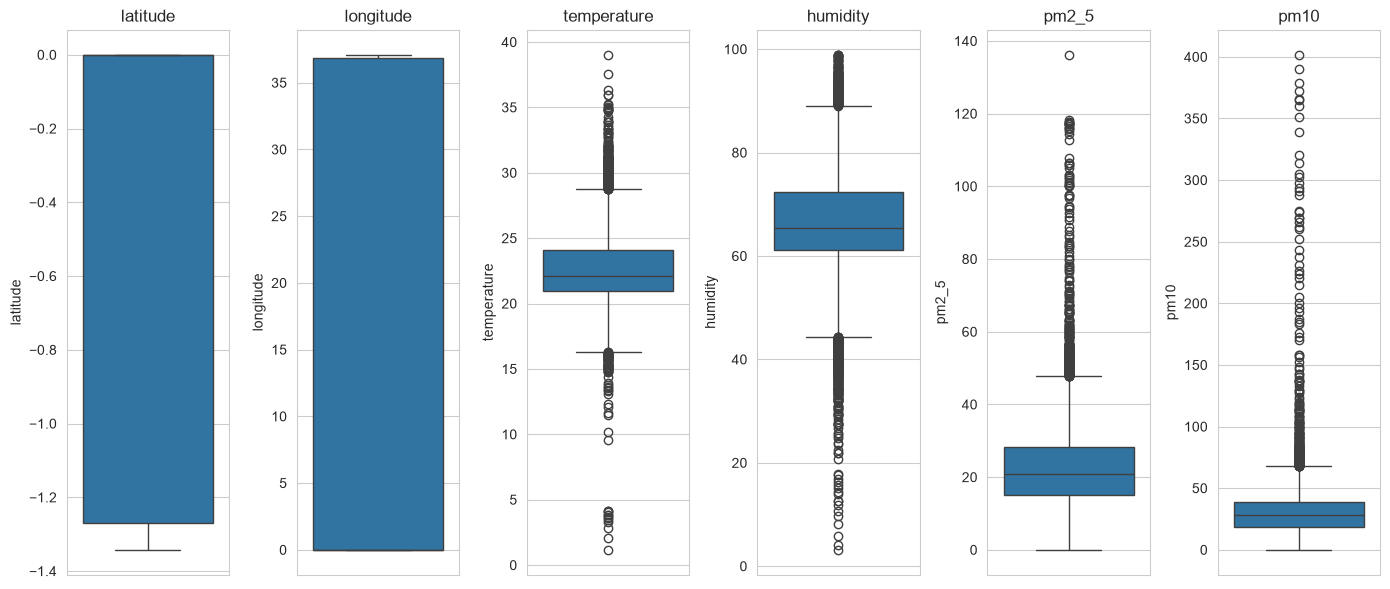

In [570]:
# managing outliers
# check for outliers in numerical columns
print("Outliers in numerical columns:")
print(air_data[numerical_cols].describe(percentiles=[0.01, 0.05, 0.1, 0.9, 0.95, 0.99]))

# Create boxplots to spot outliers visually
plt.figure(figsize=(14, 6))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, len(numerical_cols), i)
    sns.boxplot(y=air_data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [571]:
# IQR Method to remove the outliers
Q1 = air_data[numerical_cols].quantile(0.25)
Q3 = air_data[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
mask = ~((air_data[numerical_cols] < (Q1 - 1.5 * IQR)) | (air_data[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
air_data_clean = air_data[mask]

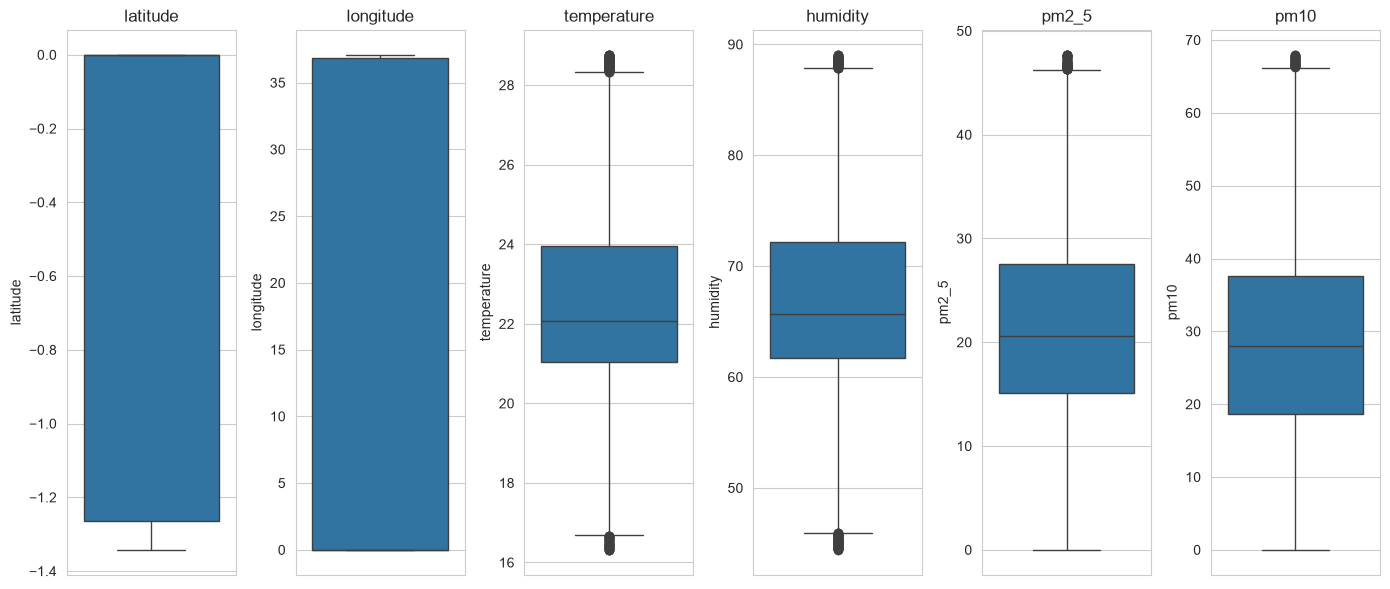

In [572]:
# boxplot to see if the outliers were removed
plt.figure(figsize=(14, 6))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, len(numerical_cols), i)
    sns.boxplot(y=air_data_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [573]:
# categorical variables
print('Categorical Columns:', air_data_clean.select_dtypes(include=['str']).columns)

# check for unique values for the categorical variables
for col in air_data_clean.select_dtypes(include=['str']).columns:
    print(col, ':', air_data_clean[col].nunique())
    print('-' * 50)
    print('The Unique values are:', air_data_clean[col].unique())

Categorical Columns: Index(['site_name'], dtype='str')
site_name : 74
--------------------------------------------------
The Unique values are: <ArrowStringArray>
[                     'athi, nairobi',                          'baba dogo',
        'birongo square nairobi west',                         'buruburu i',
 'buruburu, makadara, nairobi, kenya',                             'chokaa',
                        'dandora iii',                    'dandora phase i',
                   'dandora phase ii',                    'dennis pritt rd',
    'donholm, embakasi east, nairobi',              'drumvale drive kamulu',
              'fire station, nairobi',                        'githurai 44',
                      'huruma estate',                    'industrial area',
                         'jkuat ieet',                          'juja road',
                      'kabete vetlab',                            'kabiria',
                             'kagira',                      'kangun

In [574]:
# split the data into train and test
X = air_data_clean.drop(columns=['pm2_5'])
y = air_data_clean['pm2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.drop(columns=['datetime'], errors='ignore')
X_test = X_test.drop(columns=['datetime'], errors='ignore')

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (12202, 6)
Test shape: (3051, 6)


In [575]:
# one hot encoding for site_name on train and test separately
X_train = pd.get_dummies(X_train, columns=['site_name'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['site_name'], drop_first=True)

# align columns (in case test is missing some categories)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
X_train.head()

Train shape: (12202, 78)
Test shape: (3051, 78)


,latitude,longitude,temperature,humidity,pm10,site_name_baba dogo,site_name_birongo square nairobi west,site_name_buruburu i,"site_name_buruburu, makadara, nairobi, kenya",site_name_chokaa,...,site_name_ruaka road runda,site_name_thawabu,site_name_uhuru estate buruburu,site_name_uhuru gardens,site_name_uhuru park,site_name_un avenue gigiri,site_name_uon parklands campus,site_name_ushirika dandora v,site_name_visa oshwal parklands,site_name_woodley kibera
246,0.000000,0.000000,21.203832,69.847118,61.50,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11428,0.000000,0.000000,24.506552,63.547404,11.60,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4546,0.000000,0.000000,26.010431,48.433105,47.38,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11567,-1.285958,36.817324,26.362197,61.991018,27.04,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2923,0.000000,0.000000,22.632936,68.230273,16.03,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


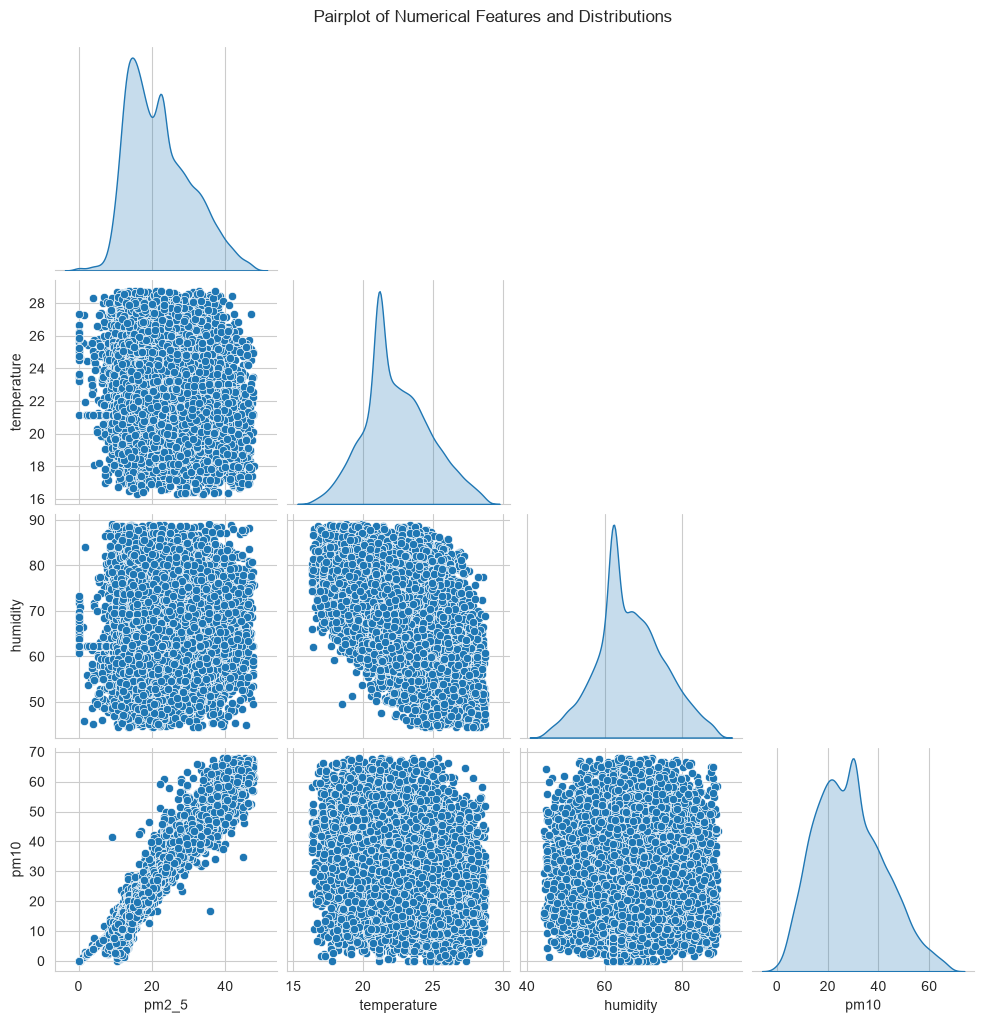

In [576]:
# feature distribution before scaling using pairplot
sns.pairplot(air_data_clean[['pm2_5', 'temperature', 'humidity', 'pm10']], diag_kind='kde', corner=True)

plt.suptitle("Pairplot of Numerical Features and Distributions", y=1.02)
plt.show()

In [577]:
# feature scaling for the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Exploratory Data Analysis

### EDA Overview

This section explores the dataset to answer the research questions:

1. **3.0 & 3.1** — Data overview: summary statistics, site coverage
2. **3.2 & 3.3** — Relationships & distributions: correlations, pairplots
3. **3.4 & 3.5** — PM2.5 vs PM10, weekday vs weekend patterns
4. **3.6 & 3.7** — Where is pollution worst? (by site, on a map)
5. **3.8 & 3.9** — What drives pollution? (temperature, humidity)
6. **3.10** — When is pollution worst? (monthly/seasonal trends)
7. **3.11** — Air Quality Index (AQI) categorization

### 3.0 Summary statistics

In [578]:
# Summary statistics of the cleaned dataset
print("=== Summary Statistics ===")
print(air_data_clean[['temperature', 'humidity', 'pm2_5', 'pm10']].describe().T)

print("\n=== Data coverage ===")
print(f"Total rows: {len(air_data_clean)}")
print(f"Unique sites: {air_data_clean['site_name'].nunique()}")
print(f"Date range: {air_data_clean['datetime'].min()} to {air_data_clean['datetime'].max()}")

print("\n=== Rows removed as outliers ===")
print(f"Original: {len(air_data)}")
print(f"After cleaning: {len(air_data_clean)}")
print(f"Removed: {len(air_data) - len(air_data_clean)} ({(len(air_data) - len(air_data_clean)) / len(air_data) * 100:.1f}%)")

=== Summary Statistics ===
               count       mean        std        min        25%        50%  \
temperature  15253.0  22.409344   2.341496  16.317998  21.045859  22.080129   
humidity     15253.0  66.525502   8.518013  44.417886  61.676582  65.670347   
pm2_5        15253.0  21.929879   8.497502   0.000000  15.100000  20.640000   
pm10         15253.0  28.721796  13.335145   0.000000  18.580000  27.920000   

                   75%        max  
temperature  23.959291  28.763755  
humidity     72.151865  89.064918  
pm2_5        27.570000  47.700000  
pm10         37.640000  67.980000  

=== Data coverage ===
Total rows: 15253
Unique sites: 74
Date range: 2025-01-01 00:00:00+00:00 to 2025-12-31 00:00:00+00:00

=== Rows removed as outliers ===
Original: 16374
After cleaning: 15253
Removed: 1121 (6.8%)


### 3.1 Site coverage and sample size per site

=== Sites with least coverage (top 15) ===
site_name
kenyatta university, nairobi           12
thawabu                                36
mukuru cc                              38
githurai 44                            50
kariobangi south                       54
olenguruone avenue north lavington     56
riruta                                 62
mutuini                                63
mukuru kwa reuben                      64
kariokor                              115
kiwanja                               147
kabete vetlab                         148
ruaka road runda                      155
kabiria                               156
ol leleshwa road                      156
dtype: int64

=== Sites with most coverage (top 15) ===
site_name
nairobi city hall                     317
dandora phase i                       322
industrial area                       322
mbotela jogoo rd, nairobi             326
rosslyn ridge                         326
juja road                             332

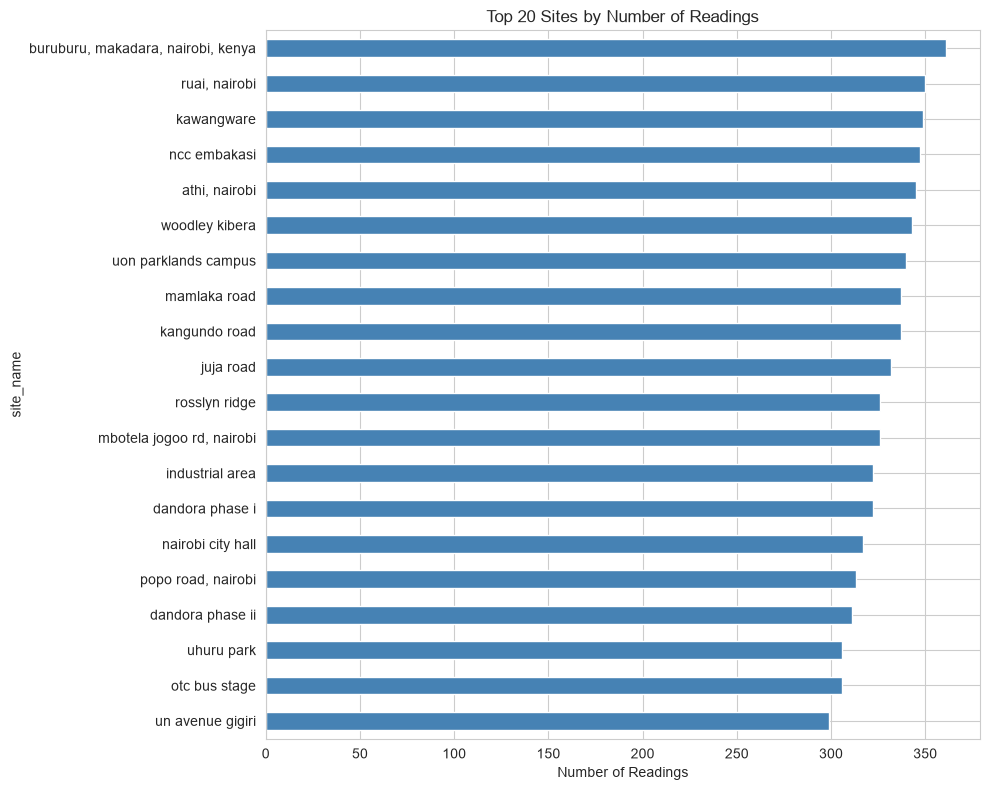

In [579]:
# Show sites with the least and most data coverage
site_counts = air_data_clean.groupby('site_name').size().sort_values()

print("=== Sites with least coverage (top 15) ===")
print(site_counts.head(15))

print("\n=== Sites with most coverage (top 15) ===")
print(site_counts.tail(15))

# Visualize coverage
plt.figure(figsize=(10, 8))
site_counts.tail(20).plot(kind='barh', color='steelblue')
plt.title("Top 20 Sites by Number of Readings")
plt.xlabel("Number of Readings")
plt.tight_layout()
plt.show()

### 3.2 Strength/direction of relationships, guides feature selection

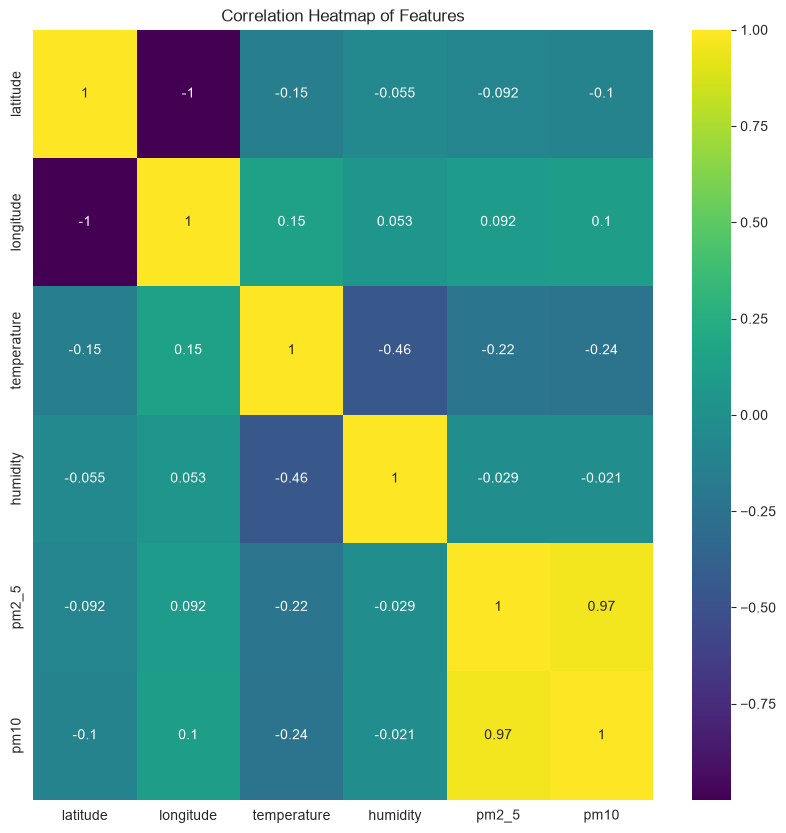

In [580]:
# correlation heatmap
plt.figure(figsize=(10,10))
sns.heatmap(air_data_clean.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap of Features")
plt.show()

### 3.3 Shape of each distribution, skewness, whether pm2_5 is right-skewed (typical for pollution data)

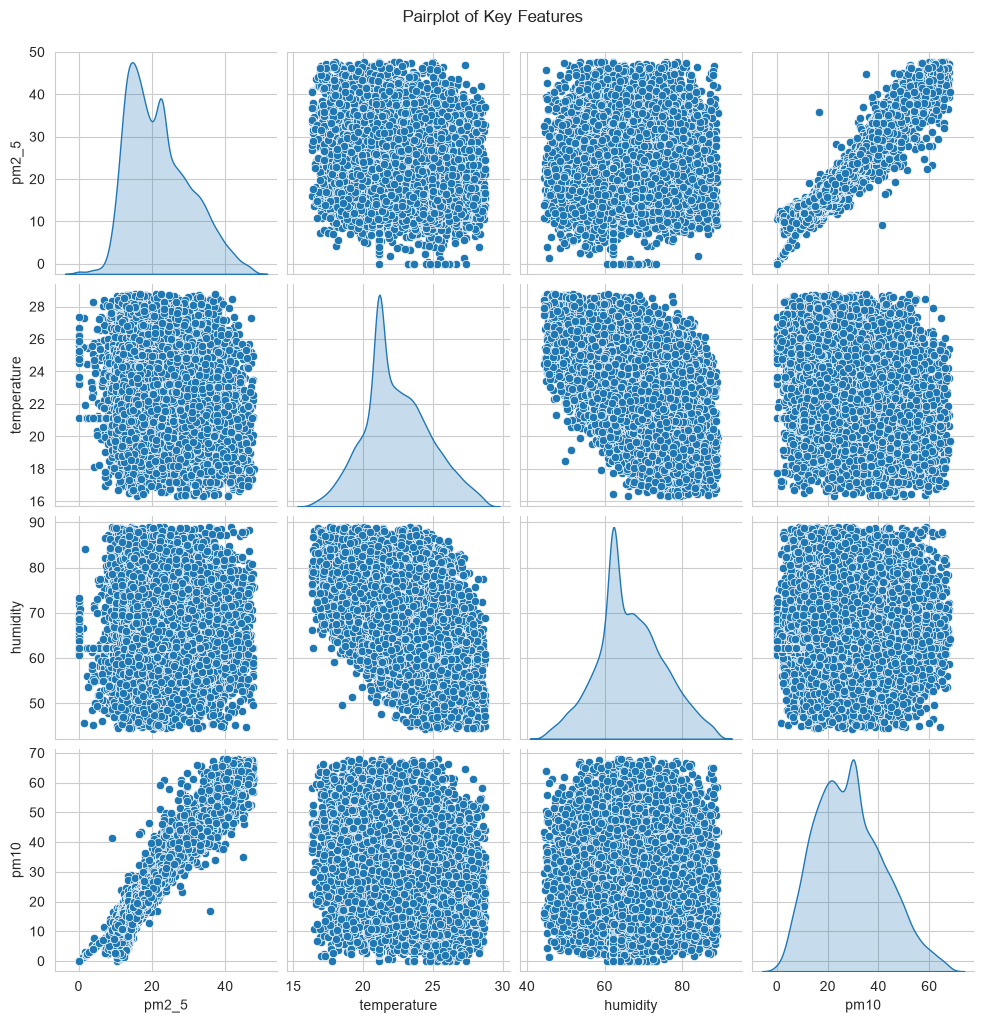

In [581]:
# histogram of of pm2_5, temperature, humidity
sns.pairplot(air_data_clean[['pm2_5', 'temperature', 'humidity', 'pm10']], diag_kind='kde')
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

### 3.4 Relationship between PM2.5 and PM10

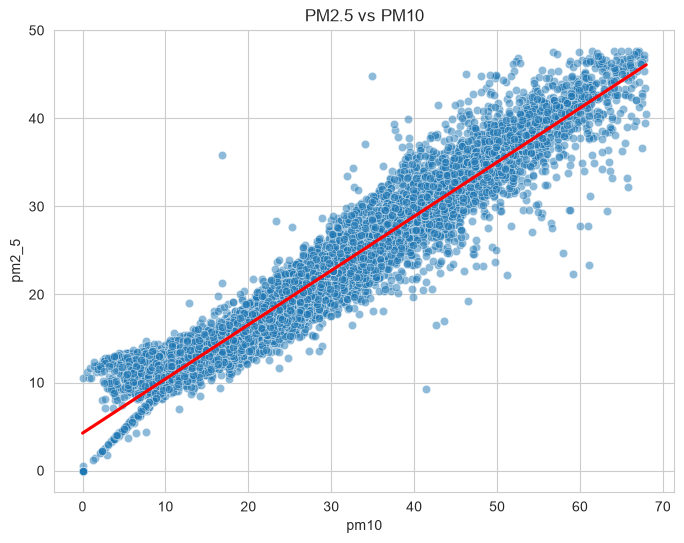

Correlation between PM2.5 and PM10: 0.966


In [582]:
# Scatter plot: PM2.5 vs PM10
plt.figure(figsize=(8, 6))
sns.scatterplot(data=air_data_clean, x='pm10', y='pm2_5', alpha=0.5)
plt.title("PM2.5 vs PM10")
plt.xlabel("PM10 (µg/m³)")
plt.ylabel("PM2.5 (µg/m³)")

# Add regression line
sns.regplot(data=air_data_clean, x='pm10', y='pm2_5', scatter=False, color='red')
plt.show()

# Correlation
corr_pm = air_data_clean[['pm2_5', 'pm10']].corr().iloc[0, 1]
print(f"Correlation between PM2.5 and PM10: {corr_pm:.3f}")

### 3.5 Weekday vs Weekend pollution

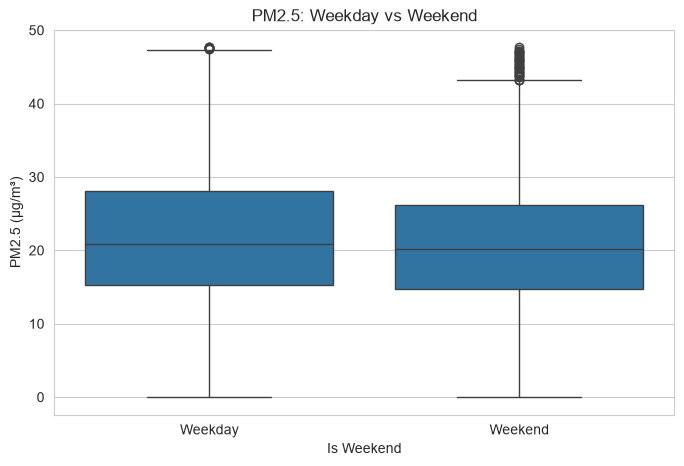

              mean  median  count
Weekday  22.200469  20.820  10899
Weekend  21.252535  20.205   4354


In [583]:
# Compare PM2.5 on weekdays vs weekends
air_data_clean['is_weekend'] = air_data_clean['datetime'].dt.weekday >= 5

plt.figure(figsize=(8, 5))
sns.boxplot(x='is_weekend', y='pm2_5', data=air_data_clean)
plt.title("PM2.5: Weekday vs Weekend")
plt.xlabel("Is Weekend")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.show()

# Summary stats
weekday_stats = air_data_clean.groupby('is_weekend')['pm2_5'].agg(['mean', 'median', 'count'])
weekday_stats.index = ['Weekday', 'Weekend']
print(weekday_stats)

### 3.6 Which locations are most polluted

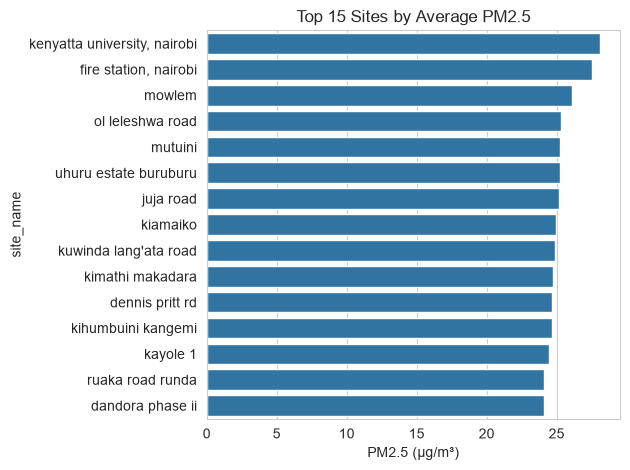

In [584]:
# bar chart of pm2_5 grouped by site_name (top 15 most polluted)
site_pm25 = air_data_clean.groupby('site_name')['pm2_5'].mean().sort_values(ascending=False).head(15)

sns.barplot(x=site_pm25.values, y=site_pm25.index)
plt.title("Top 15 Sites by Average PM2.5")
plt.xlabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

### 3.7 Geographic hotspots across Nairobi

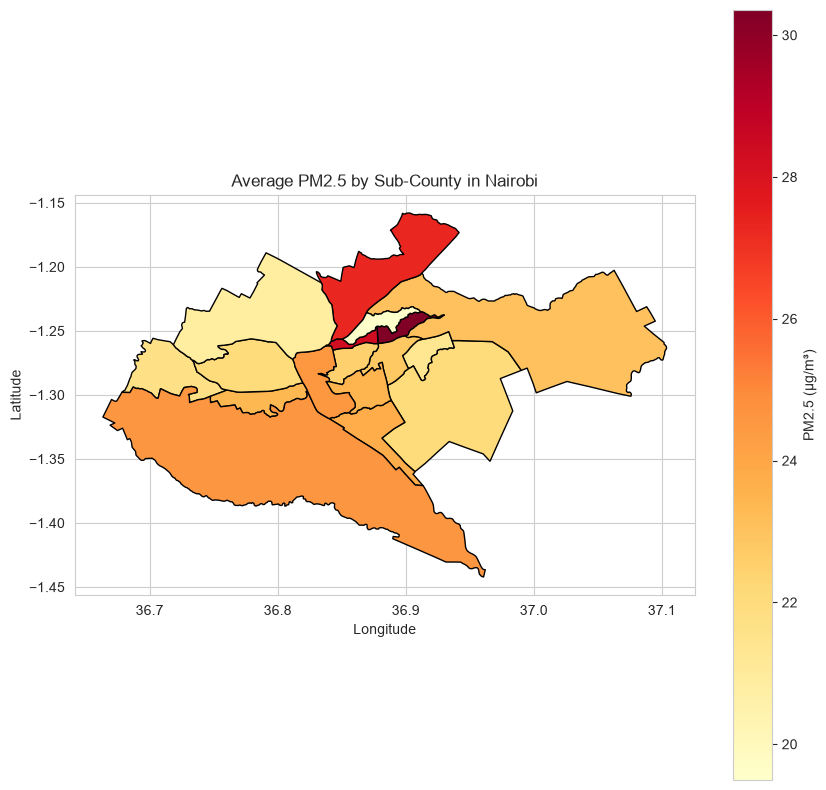

In [585]:
# Load Nairobi sub-counties
nairobi_bounds = gpd.read_file("data/ken_admin_boundaries.geojson (1)/ken_admin2.geojson")
nairobi_bounds = nairobi_bounds[nairobi_bounds['adm1_name'] == 'Nairobi']

# Filter out zero coordinates (sensor did not report location)
spatial_data = air_data_clean[(air_data_clean['latitude'] != 0) & (air_data_clean['longitude'] != 0)]

# Create GeoDataFrame from air quality data
gdf = gpd.GeoDataFrame(spatial_data, 
                        geometry=gpd.points_from_xy(spatial_data.longitude, spatial_data.latitude),
                        crs="EPSG:4326")

# Spatial join - assign each reading to a sub-county
gdf_joined = gpd.sjoin(gdf, nairobi_bounds[['adm2_name', 'geometry']], how='left', predicate='within')

# Aggregate PM2.5 by sub-county
pm25_by_area = gdf_joined.groupby('adm2_name')['pm2_5'].mean().reset_index()

# Merge back to geometry
nairobi_choro = nairobi_bounds.merge(pm25_by_area, on='adm2_name')

# Plot choropleth
fig, ax = plt.subplots(figsize=(10, 10))
nairobi_choro.plot(column='pm2_5', ax=ax, legend=True, 
                   cmap='YlOrRd', edgecolor='black',
                   legend_kwds={'label': 'PM2.5 (µg/m³)'})
ax.set_title("Average PM2.5 by Sub-County in Nairobi")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

### 3.8 Whether heat correlates with pollution levels

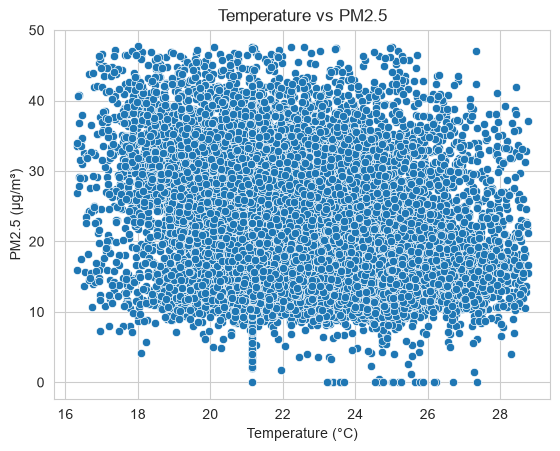

In [586]:
# Scatter plot: temperature vs pm2_5
sns.scatterplot(data=air_data_clean, x='temperature', y='pm2_5')
plt.title("Temperature vs PM2.5")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

### 3.9 Whether humidity correlates with pollution levels

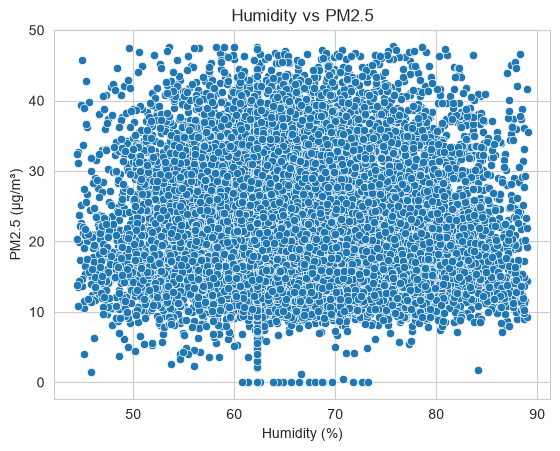

In [587]:
# scatter plot: humidity vs pm2_5
sns.scatterplot(data=air_data_clean, x='humidity', y='pm2_5')
plt.title("Humidity vs PM2.5")
plt.xlabel("Humidity (%)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

### 3.10 Seasonal patterns: PM2.5 distribution by month

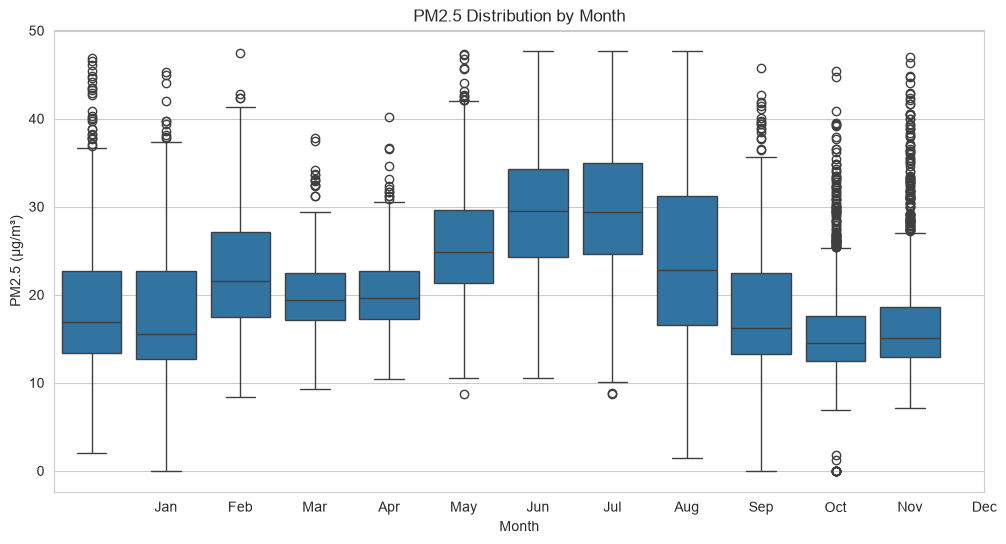

In [588]:
# Boxplot of pm2_5 by month
air_data_clean['month'] = air_data_clean['datetime'].dt.month

plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='pm2_5', data=air_data_clean)
plt.title("PM2.5 Distribution by Month")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

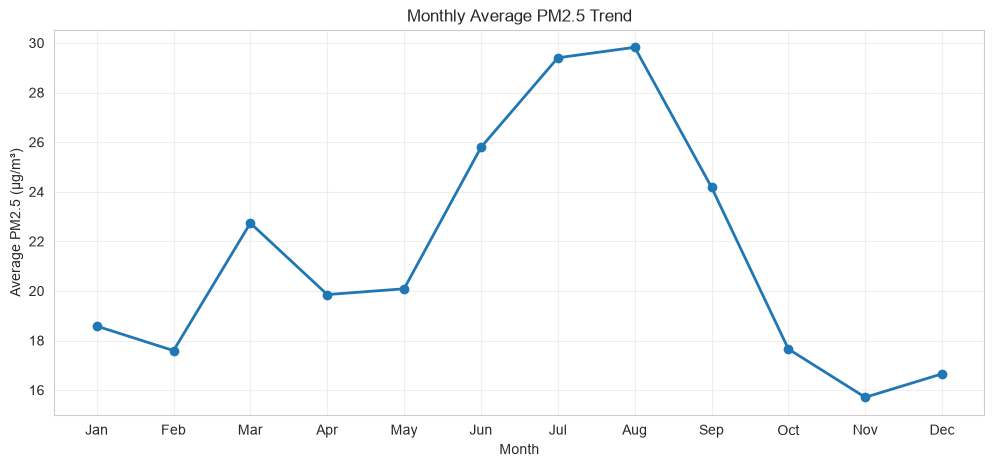

In [589]:
# Line chart: monthly average PM2.5 trend
monthly_avg = air_data_clean.groupby(air_data_clean['month'])['pm2_5'].mean()

plt.figure(figsize=(12, 5))
plt.plot(range(1, 13), monthly_avg, marker='o', linewidth=2)
plt.title("Monthly Average PM2.5 Trend")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.show()

### 3.11 Air Quality Index (AQI) categorization

In [590]:
def categorize_pm25(val):
    if val <= 12.0:
        return 'Good'
    elif val <= 35.4:
        return 'Moderate'
    else:
        return 'Unhealthy'

=== Class distribution (before handling imbalance) ===
pm2_5_category
Moderate     12755
Unhealthy     1268
Good          1230
Name: count, dtype: int64


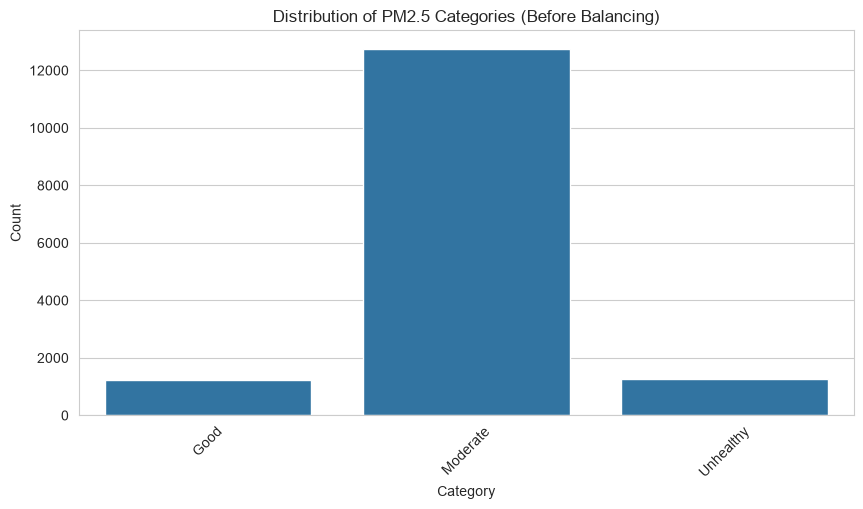

In [591]:
# Apply categorization
air_data_clean['pm2_5_category'] = air_data_clean['pm2_5'].apply(categorize_pm25)

# Show original class distribution
print("=== Class distribution (before handling imbalance) ===")
class_counts = air_data_clean['pm2_5_category'].value_counts()
print(class_counts)

# Count plot of original distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='pm2_5_category', data=air_data_clean, order=['Good', 'Moderate', 'Unhealthy'])
plt.title("Distribution of PM2.5 Categories (Before Balancing)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### 3.12 Handling class imbalance with SMOTE

The majority class (Moderate) dominates. We balance the classes so the classifier learns all categories fairly.

In [592]:
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import LabelEncoder

# Prepare features for balancing (numeric features only for now)
balance_features = ['temperature', 'humidity', 'pm10', 'latitude', 'longitude']
X_bal = air_data_clean[balance_features].copy()
y_bal = air_data_clean['pm2_5_category']

# Encode categories to numeric labels
le = LabelEncoder()
y_bal_encoded = le.fit_transform(y_bal)
print("Class labels:", dict(zip(le.classes_, range(len(le.classes_)))))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_bal, y_bal_encoded)

# Check balanced counts
balanced_counts = pd.Series(y_resampled).value_counts().sort_index()
balanced_counts.index = le.classes_[balanced_counts.index.astype(int)]
print("\n=== Class distribution (after SMOTE balancing) ===")
print(balanced_counts)

Class labels: {'Good': 0, 'Moderate': 1, 'Unhealthy': 2}

=== Class distribution (after SMOTE balancing) ===
Good         12755
Moderate     12755
Unhealthy    12755
Name: count, dtype: int64


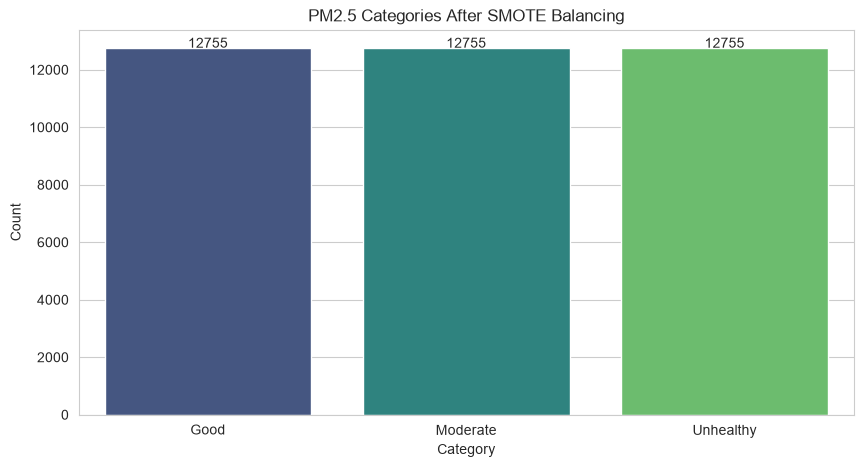

In [593]:
# Visualize balanced distribution
balanced_df = balanced_counts.reset_index()
balanced_df.columns = ['Category', 'Count']
balanced_df = balanced_df.set_index('Category')

plt.figure(figsize=(10, 5))
sns.barplot(data=balanced_df.reset_index(), x='Category', y='Count',
            hue='Category', palette='viridis', legend=False)
for i, v in enumerate(balanced_counts.values):
    plt.text(i, v + 10, str(v), ha='center')
plt.title("PM2.5 Categories After SMOTE Balancing")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

## 4. Feature Engineering & Selection

### 4.1 Datetime decomposition

In [594]:
# Extract year, month, day, day_of_week, is_weekend from datetime
air_data_clean['year'] = air_data_clean['datetime'].dt.year
air_data_clean['month'] = air_data_clean['datetime'].dt.month
air_data_clean['day'] = air_data_clean['datetime'].dt.day
air_data_clean['day_of_week'] = air_data_clean['datetime'].dt.dayofweek
air_data_clean['is_weekend'] = air_data_clean['datetime'].dt.weekday >= 5

# Check the new columns
air_data_clean[['year', 'month', 'day', 'day_of_week', 'is_weekend']].head()

,year,month,day,day_of_week,is_weekend
0,2025,1,1,2,False
1,2025,1,2,3,False
2,2025,1,3,4,False
3,2025,1,4,5,True
4,2025,1,5,6,True


In [595]:
# Cyclical encoding of month/day_of_week (sin/cos transform)
air_data_clean['month_sin'] = np.sin(2 * np.pi * air_data_clean['month'] / 12)
air_data_clean['month_cos'] = np.cos(2 * np.pi * air_data_clean['month'] / 12)
air_data_clean['day_sin'] = np.sin(2 * np.pi * air_data_clean['day_of_week'] / 7)
air_data_clean['day_cos'] = np.cos(2 * np.pi * air_data_clean['day_of_week'] / 7)

# Check the new columns
air_data_clean[['month_sin', 'month_cos', 'day_sin', 'day_cos']].head()

,month_sin,month_cos,day_sin,day_cos
0,0.5,0.866025,0.974928,-0.222521
1,0.5,0.866025,0.433884,-0.900969
2,0.5,0.866025,-0.433884,-0.900969
3,0.5,0.866025,-0.974928,-0.222521
4,0.5,0.866025,-0.781831,0.623490


### 4.2 Site encoding

In [596]:
from sklearn.preprocessing import LabelEncoder

# Encode site_name as numeric labels
le_site = LabelEncoder()
air_data_clean['site_encoded'] = le_site.fit_transform(air_data_clean['site_name'])

print(f"Sites encoded: {le_site.classes_.tolist()}")
air_data_clean[['site_name', 'site_encoded']].head()

Sites encoded: ['athi, nairobi', 'baba dogo', 'birongo square nairobi west', 'buruburu i', 'buruburu, makadara, nairobi, kenya', 'chokaa', 'dandora iii', 'dandora phase i', 'dandora phase ii', 'dennis pritt rd', 'donholm, embakasi east, nairobi', 'drumvale drive kamulu', 'fire station, nairobi', 'githurai 44', 'huruma estate', 'industrial area', 'jkuat ieet', 'juja road', 'kabete vetlab', 'kabiria', 'kagira', 'kangundo road', 'karen', 'kariobangi south', 'kariokor', 'karura forest', 'kasarani', 'kasarani mwiki road', 'kawangware', 'kayole 1', 'kenyatta university, nairobi', 'kiamaiko', 'kibra', 'kifaru umoja ii', 'kihumbuini kangemi', 'kimathi makadara', 'kiwanja', "kuwinda lang'ata road", 'langata', 'lower kabete', 'makadara', 'mamlaka road', 'manyatta ruai', 'marurui', 'mbagathi', 'mbotela jogoo rd, nairobi', 'mihango', 'mowlem', 'muguga westlands', 'mukuru cc', 'mukuru hc', 'mukuru kwa reuben', 'mutuini', 'nairobi city hall', 'ncc embakasi', 'ol leleshwa road', 'olenguruone avenue n

,site_name,site_encoded
0,"athi, nairobi",0
1,"athi, nairobi",0
2,"athi, nairobi",0
3,"athi, nairobi",0
4,"athi, nairobi",0


### 4.3 Lagged & rolling features

Since this is daily time-series data, yesterday's pollution often predicts today's. We create lag-1 and rolling averages per site.

In [597]:
# Sort by datetime for correct lagging
air_data_clean = air_data_clean.sort_values('datetime').reset_index(drop=True)

# Lag-1 and rolling-mean (7-day) features, computed per site
air_data_clean['pm2_5_lag1'] = air_data_clean.groupby('site_name')['pm2_5'].shift(1)
air_data_clean['pm2_5_roll7'] = air_data_clean.groupby('site_name')['pm2_5'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
air_data_clean['temp_roll7'] = air_data_clean.groupby('site_name')['temperature'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

# Drop the first row per site (has no lag value)
air_data_clean = air_data_clean.dropna(subset=['pm2_5_lag1'])

print(f"Rows after lag feature engineering: {len(air_data_clean)}")
air_data_clean[['site_name', 'pm2_5', 'pm2_5_lag1', 'pm2_5_roll7', 'temp_roll7']].head(10)

Rows after lag feature engineering: 15179


,site_name,pm2_5,pm2_5_lag1,pm2_5_roll7,temp_roll7
19,kawangware,13.290000,12.99,13.140000,23.832902
20,otc bus stage,13.680000,10.50,12.090000,26.903309
21,kuwinda lang'ata road,12.490000,14.52,13.505000,25.379135
22,baba dogo,8.850000,8.38,8.615000,24.662122
23,kangundo road,10.430000,9.14,9.785000,24.171452
24,nairobi city hall,19.870000,17.27,18.570000,27.708063
25,juja road,22.670993,46.12,34.395496,20.835315
27,uon parklands campus,14.200000,14.58,14.390000,25.322763
28,"ruai, nairobi",15.550000,15.52,15.535000,23.983288
29,mamlaka road,13.340000,13.37,13.355000,25.295265


### 4.4 Feature selection

We drop highly correlated or low-information features and select the final feature set for modeling.

In [598]:
# Define the final feature set (features that make sense for prediction)
features = [
    'temperature', 'humidity', 'pm10',
    'latitude', 'longitude',
    'site_encoded',
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'is_weekend',
    'pm2_5_lag1', 'pm2_5_roll7', 'temp_roll7'
]

# Correlation with target
print("=== Correlation with PM2.5 ===")
corr_with_target = air_data_clean[features + ['pm2_5']].corr()['pm2_5'].sort_values(ascending=False)
print(corr_with_target)

=== Correlation with PM2.5 ===
pm2_5           1.000000
pm10            0.965635
pm2_5_roll7     0.788231
pm2_5_lag1      0.669945
longitude       0.093220
day_sin         0.040861
site_encoded   -0.021873
day_cos        -0.029960
humidity       -0.030135
is_weekend     -0.049529
latitude       -0.093984
month_sin      -0.182525
temperature    -0.222275
temp_roll7     -0.240549
month_cos      -0.509143
Name: pm2_5, dtype: float64


## 5. Model Selection

We compare multiple **regression** and **classification** models to find the best predictor of PM2.5.

### 5.1 Data split (regression + classification targets)

In [599]:
from sklearn.model_selection import train_test_split

X = air_data_clean[features]

# Regression target
y_reg = air_data_clean['pm2_5']

# Classification target (already created in EDA)
y_clf = air_data_clean['pm2_5_category']

# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Classification split (stratified to preserve class balance)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Regression  -> Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")
print(f"Classification -> Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")
print(f"\nClass balance in train set:\n{y_train_clf.value_counts()}")

Regression  -> Train: (12143, 14), Test: (3036, 14)
Classification -> Train: (12143, 14), Test: (3036, 14)

Class balance in train set:
pm2_5_category
Moderate     10158
Unhealthy     1011
Good           974
Name: count, dtype: int64


### 5.2 Feature scaling

In [600]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

print("Features scaled to mean=0, std=1")
print(f"Train (reg): {X_train_reg_scaled.shape}, Test (reg): {X_test_reg_scaled.shape}")

Features scaled to mean=0, std=1
Train (reg): (12143, 14), Test (reg): (3036, 14)


### 5.3 Regression models comparison

Each regression model is trained in its own cell, then results are compared at the end.
### 5.3.1 Linear Regression

In [601]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_linear = linear_reg.predict(X_test_reg_scaled)

print("=== Linear Regression ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)):.4f}")
print(f"MAE : {mean_absolute_error(y_test_reg, y_pred_linear):.4f}")
print(f"R²  : {r2_score(y_test_reg, y_pred_linear):.4f}")

=== Linear Regression ===
RMSE: 2.2305
MAE : 1.6253
R²  : 0.9325


### 5.3.2 Ridge Regression

In [602]:
from sklearn.linear_model import Ridge

# Train Ridge Regression
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_ridge = ridge_reg.predict(X_test_reg_scaled)

print("=== Ridge Regression ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)):.4f}")
print(f"MAE : {mean_absolute_error(y_test_reg, y_pred_ridge):.4f}")
print(f"R²  : {r2_score(y_test_reg, y_pred_ridge):.4f}")

=== Ridge Regression ===
RMSE: 2.2307
MAE : 1.6256
R²  : 0.9325


### 5.3.3 Random Forest Regressor

In [603]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_rf = rf_reg.predict(X_test_reg_scaled)

print("=== Random Forest Regressor ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)):.4f}")
print(f"MAE : {mean_absolute_error(y_test_reg, y_pred_rf):.4f}")
print(f"R²  : {r2_score(y_test_reg, y_pred_rf):.4f}")

=== Random Forest Regressor ===
RMSE: 1.9674
MAE : 1.3196
R²  : 0.9475


### 5.3.4 Polynomial Regression (degree 2)

In [604]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Polynomial Regression (degree 2): PolynomialFeatures -> Scale -> LinearRegression
poly_reg = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression()
)
poly_reg.fit(X_train_reg, y_train_reg)
y_pred_poly = poly_reg.predict(X_test_reg)

print("=== Polynomial Regression (degree 2) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_poly)):.4f}")
print(f"MAE : {mean_absolute_error(y_test_reg, y_pred_poly):.4f}")
print(f"R²  : {r2_score(y_test_reg, y_pred_poly):.4f}")

=== Polynomial Regression (degree 2) ===
RMSE: 2.0926
MAE : 1.4948
R²  : 0.9406


### 5.3.5 Regression models summary & best model

In [605]:
reg_results = {
    'Linear Regression': {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)),
        'MAE': mean_absolute_error(y_test_reg, y_pred_linear),
        'R²': r2_score(y_test_reg, y_pred_linear)
    },
    'Ridge Regression': {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)),
        'MAE': mean_absolute_error(y_test_reg, y_pred_ridge),
        'R²': r2_score(y_test_reg, y_pred_ridge)
    },
    'Random Forest': {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)),
        'MAE': mean_absolute_error(y_test_reg, y_pred_rf),
        'R²': r2_score(y_test_reg, y_pred_rf)
    },
    'Polynomial (deg 2)': {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_poly)),
        'MAE': mean_absolute_error(y_test_reg, y_pred_poly),
        'R²': r2_score(y_test_reg, y_pred_poly)
    }
}

reg_summary = pd.DataFrame(reg_results).T.round(4)
print("=== Regression Model Comparison ===")
print(reg_summary)

best_reg = reg_summary['R²'].idxmax()
print(f"\n>>> Best regression model: {best_reg} (R² = {reg_summary.loc[best_reg, 'R²']})")

=== Regression Model Comparison ===
                      RMSE     MAE      R²
Linear Regression   2.2305  1.6253  0.9325
Ridge Regression    2.2307  1.6256  0.9325
Random Forest       1.9674  1.3196  0.9475
Polynomial (deg 2)  2.0926  1.4948  0.9406

>>> Best regression model: Random Forest (R² = 0.9475)


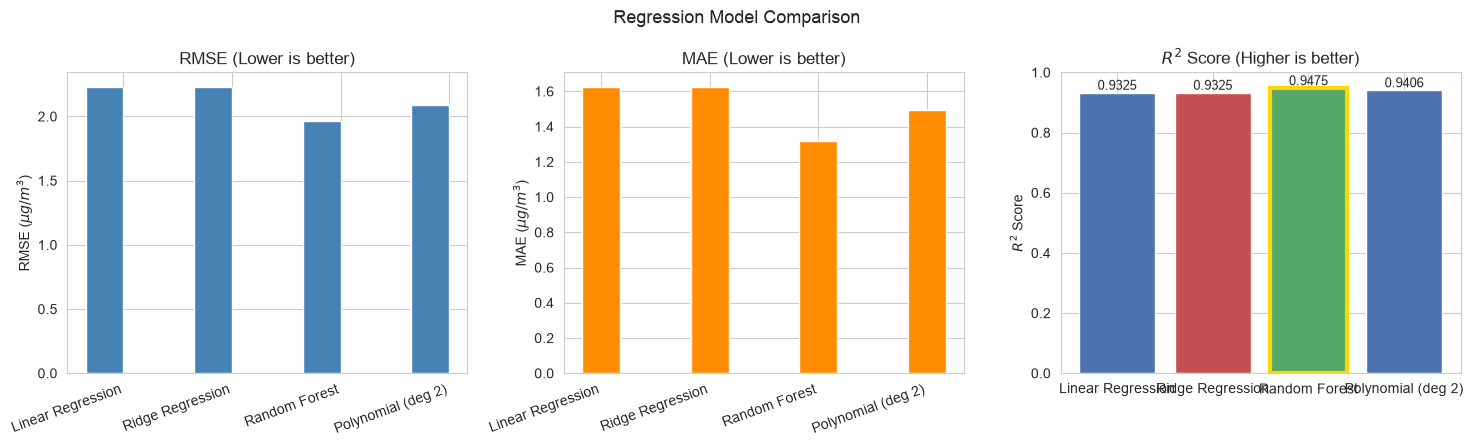

In [606]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

models = reg_summary.index
x = np.arange(len(models))
width = 0.35

# 1st graph: RMSE
axes[0].bar(x - width/2, reg_summary['RMSE'], width, label='RMSE', color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha='right')
axes[0].set_ylabel(r'RMSE ($\mu g/m^3$)')
axes[0].set_title('RMSE (Lower is better)')

# 2nd graph: MAE
axes[1].bar(x, reg_summary['MAE'], width, label='MAE', color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha='right')
axes[1].set_ylabel(r'MAE ($\mu g/m^3$)')
axes[1].set_title('MAE (Lower is better)')

# 3rd graph: R² Score
bars = axes[2].bar(models, reg_summary['R²'], color=['#4C72B0', '#C44E52', '#55A868'])
axes[2].set_ylabel('$R^2$ Score')
axes[2].set_title('$R^2$ Score (Higher is better)')
axes[2].set_ylim(0, 1)

for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.4f}", ha='center', fontsize=9)

# Highlight best model on R²
best_idx = np.argmax(reg_summary['R²'])
axes[2].patches[best_idx].set_edgecolor('gold')
axes[2].patches[best_idx].set_linewidth(3)

plt.suptitle('Regression Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

### 5.4 Classification models comparison

Each classification model is trained in its own cell, then results are compared at the end.

In [607]:
from sklearn.preprocessing import LabelEncoder

# Encode category labels (Good=0, Moderate=1, Unhealthy=2)
le = LabelEncoder()
y_train_clf_enc = le.fit_transform(y_train_clf)
y_test_clf_enc = le.transform(y_test_clf)
print("Classes:", list(le.classes_))

Classes: ['Good', 'Moderate', 'Unhealthy']


### 5.4.1 Logistic Regression

In [608]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_clf_scaled, y_train_clf_enc)
y_pred_logreg = logreg.predict(X_test_clf_scaled)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test_clf_enc, y_pred_logreg):.4f}")
print(classification_report(y_test_clf_enc, y_pred_logreg, target_names=le.classes_))

=== Logistic Regression ===
Accuracy: 0.9025
              precision    recall  f1-score   support

        Good       0.62      0.48      0.54       243
    Moderate       0.93      0.96      0.94      2540
   Unhealthy       0.87      0.72      0.79       253

    accuracy                           0.90      3036
   macro avg       0.80      0.72      0.76      3036
weighted avg       0.90      0.90      0.90      3036



### 5.4.2 Random Forest Classifier

In [609]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_clf.fit(X_train_clf_scaled, y_train_clf_enc)
y_pred_rf_clf = rf_clf.predict(X_test_clf_scaled)

print("=== Random Forest Classifier ===")
print(f"Accuracy: {accuracy_score(y_test_clf_enc, y_pred_rf_clf):.4f}")
print(classification_report(y_test_clf_enc, y_pred_rf_clf, target_names=le.classes_))

=== Random Forest Classifier ===
Accuracy: 0.9219
              precision    recall  f1-score   support

        Good       0.68      0.81      0.74       243
    Moderate       0.97      0.94      0.95      2540
   Unhealthy       0.76      0.89      0.82       253

    accuracy                           0.92      3036
   macro avg       0.80      0.88      0.84      3036
weighted avg       0.93      0.92      0.92      3036



### 5.4.3 Classification models summary & best model

In [610]:
from sklearn.metrics import accuracy_score, f1_score

clf_results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test_clf_enc, y_pred_logreg),
        'Macro-F1': f1_score(y_test_clf_enc, y_pred_logreg, average='macro')
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test_clf_enc, y_pred_rf_clf),
        'Macro-F1': f1_score(y_test_clf_enc, y_pred_rf_clf, average='macro')
    }
}

clf_summary = pd.DataFrame(clf_results).T.round(4)
print("=== Classification Model Comparison ===")
print(clf_summary)

best_clf = clf_summary['Accuracy'].idxmax()
print(f"\n>>> Best classification model: {best_clf} (Accuracy = {clf_summary.loc[best_clf, 'Accuracy']})")

=== Classification Model Comparison ===
                     Accuracy  Macro-F1
Logistic Regression    0.9025    0.7573
Random Forest          0.9219    0.8378

>>> Best classification model: Random Forest (Accuracy = 0.9219)


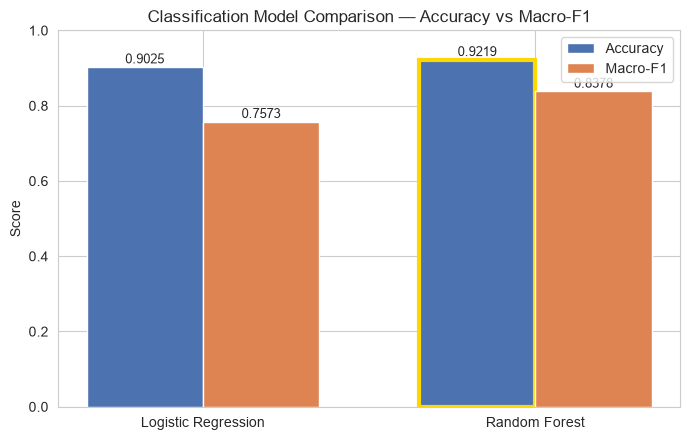

In [611]:
# Bar chart of Accuracy vs Macro-F1 per classifier
fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(len(clf_summary.index))
width = 0.35
acc_bars = ax.bar(x - width/2, clf_summary['Accuracy'], width, label='Accuracy', color='#4C72B0')
f1_bars = ax.bar(x + width/2, clf_summary['Macro-F1'], width, label='Macro-F1', color='#DD8452')

ax.set_xticks(x); ax.set_xticklabels(clf_summary.index)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison — Accuracy vs Macro-F1')
ax.legend()

for bars in [acc_bars, f1_bars]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.4f}", ha='center', fontsize=9)

best_idx = np.argmax(clf_summary['Accuracy'])
acc_bars[best_idx].set_edgecolor('gold'); acc_bars[best_idx].set_linewidth(3)
plt.tight_layout()
plt.show()

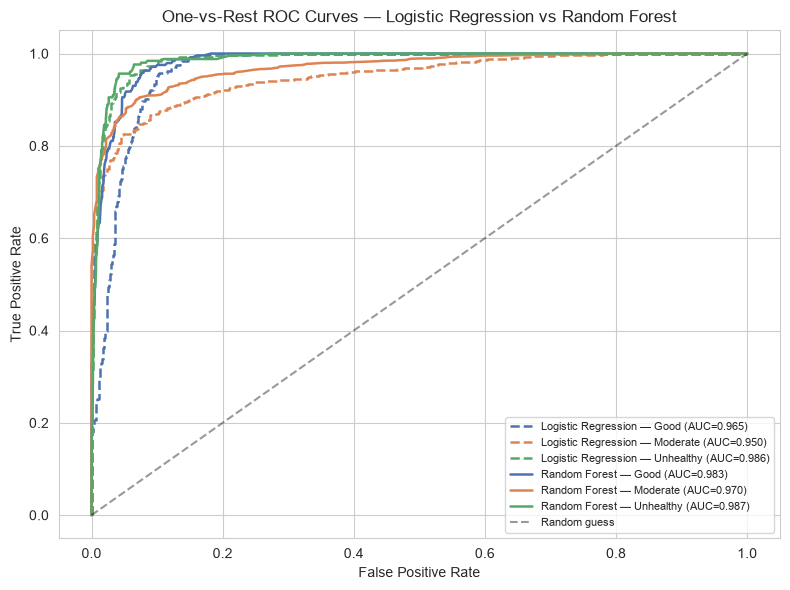

In [612]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# One-vs-rest ROC curves for all 3 classes
y_test_bin = label_binarize(y_test_clf_enc, classes=np.arange(len(class_names)))

logreg_proba = logreg.predict_proba(X_test_clf_scaled)
rf_proba = rf_clf.predict_proba(X_test_clf_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']
linestyles = ['--', '-']
labels_dict = {'logreg': 'Logistic Regression', 'rf': 'Random Forest'}

for model_idx, (model_name, proba) in enumerate([('logreg', logreg_proba), ('rf', rf_proba)]):
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linestyle=linestyles[model_idx], color=colors[i],
                label=f'{labels_dict[model_name]} — {cls_name} (AUC={roc_auc:.3f})', linewidth=1.8)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('One-vs-Rest ROC Curves — Logistic Regression vs Random Forest')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 5.5 Classification with SMOTE-balanced training data

In [613]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only (never to test data)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clf_scaled, y_train_clf_enc)

# Class counts before SMOTE (train set)
counts_before = pd.Series(y_train_clf_enc).value_counts().sort_index()
print(f"SMOTE shapes -> X: {X_train_smote.shape}, y: {y_train_smote.shape}")
print("Class counts before SMOTE:", dict(counts_before))
print("Balanced class counts:", dict(zip(*np.unique(y_train_smote, return_counts=True))))

# Retrain Random Forest on balanced data
rf_clf_smote = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_clf_smote.predict(X_test_clf_scaled)

print(f"\nRandom Forest (SMOTE): Accuracy = {accuracy_score(y_test_clf_enc, y_pred_smote):.4f}")
print(classification_report(y_test_clf_enc, y_pred_smote, target_names=le.classes_))

SMOTE shapes -> X: (30474, 14), y: (30474,)
Class counts before SMOTE: {0: np.int64(974), 1: np.int64(10158), 2: np.int64(1011)}
Balanced class counts: {np.int64(0): np.int64(10158), np.int64(1): np.int64(10158), np.int64(2): np.int64(10158)}

Random Forest (SMOTE): Accuracy = 0.9203
              precision    recall  f1-score   support

        Good       0.68      0.81      0.74       243
    Moderate       0.97      0.93      0.95      2540
   Unhealthy       0.75      0.89      0.81       253

    accuracy                           0.92      3036
   macro avg       0.80      0.88      0.83      3036
weighted avg       0.93      0.92      0.92      3036

